# Task 4: Binary Classification (Ischemic vs. Non-Ischemic)

## 1. Data Loading & Label Integration
In this step, we establish our dataset $D = \{(X, y)\}$ by integrating two distinct sources:
1.  **Patient Clinical Profile ($X$):** The cleaned tabular data representing patient history and admission metrics (View 2).
2.  **Ground Truth Labels ($y$):** We load the pre-computed labels from `subject_to_labels_ischemic.csv`. This ensures our target variable $y$ (Ischemic = 1, Non-Ischemic = 0) is consistent with the verified ICD code definitions (I20-I25) defined in our project guidelines.

**Theoretical Note:**
Before training, we must analyze the distribution of $y$. If the classes are significantly skewed (e.g., one class < 20%), standard accuracy will be a misleading metric. As per the **Imbalanced Learning** theory, we will need to identify this ratio early to decide whether to apply strategies like **Cost-Sensitive Learning** (Class Weights) or **Resampling** (SMOTE) in the modeling phase.

**Action:**
* Load the clinical features and label file.
* Merge them on `subject_id` using an inner join to ensure we only train on patients with both data and valid labels.
* Remove any ECG-related data to focus strictly on the tabular patient profile.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Configuration ---
DATA_DIR = Path('../Data')
PATH_PROFILE = DATA_DIR / 'view2_clean_for_clustering.csv'
PATH_LABELS  = DATA_DIR / 'subject_to_labels_ischemic.csv'

print("--- 1. Loading Clinical Data & Labels ---")

# 1. Load Data
try:
    df_profile = pd.read_csv(PATH_PROFILE)
    df_labels = pd.read_csv(PATH_LABELS)
    print(f"✅ Patient Profile Loaded: {df_profile.shape}")
    print(f"✅ Labels Loaded: {df_labels.shape}")
    print(f"   Label Columns found: {df_labels.columns.tolist()}")
except FileNotFoundError as e:
    print(f"❌ Error: File not found. {e}")
    raise

# 2. Standardize Keys
df_profile['subject_id'] = df_profile['subject_id'].astype(int)
df_labels['subject_id'] = df_labels['subject_id'].astype(int)

# 3. Dynamic Column Identification & Renamingl
available_cols = [c for c in df_labels.columns if c != 'subject_id']

if not available_cols:
    raise ValueError("The label file contains only 'subject_id'. No target column found.")

original_target_col = available_cols[0]
print(f" Identified target column: '{original_target_col}'. Renaming to 'label'.")

df_labels.rename(columns={original_target_col: 'label'}, inplace=True)

# 4. Merge Features (X) with Labels (y)
df_clinical = pd.merge(df_profile, df_labels, on='subject_id', how='inner')

# 5. Feature Selection (Strictly Clinical Profile)
# Removing IDs and any potential ECG data (if present in view2)
cols_to_drop = ['hadm_id', 'note_id', 'charttime'] 
df_clinical = df_clinical.drop(columns=[c for c in cols_to_drop if c in df_clinical.columns], errors='ignore')

# 6. Class Distribution Analysis (Theory: Imbalanced Learning)
class_counts = df_clinical['label'].value_counts()
imbalance_ratio = class_counts.get(0, 0) / class_counts.get(1, 1) # Prevent div by zero

print(f"\n--- Dataset Construction Complete ---")
print(f"Final Data Shape: {df_clinical.shape}")
print(f"Class Distribution:\n{class_counts}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1 (Negative:Positive)")

if imbalance_ratio > 1.5 or imbalance_ratio < 0.6:
    print(" Dataset is Imbalanced. We will need to use Class Weights or Resampling.")
else:
    print("Dataset is relatively balanced.")

# Preview
df_clinical.head()

--- 1. Loading Clinical Data & Labels ---
✅ Patient Profile Loaded: (4864, 19)
✅ Labels Loaded: (4392, 2)
   Label Columns found: ['subject_id', 'label_ischemic']
ℹ️  Identified target column: 'label_ischemic'. Renaming to 'label'.

--- Dataset Construction Complete ---
Final Data Shape: (4864, 19)
Class Distribution:
label
0    2626
1    2238
Name: count, dtype: int64
Imbalance Ratio: 1.17:1 (Negative:Positive)
✅ Dataset is relatively balanced.


,subject_id,total_lab_events,abnormal_ratio,max_glucose,max_troponin,max_wbc,max_creatinine,max_potassium,max_hba1c,min_albumin,min_platelet,total_microbio_events,resistant_count,distinct_organisms,total_procedures,num_diagnoses,resistant_ratio,proc_per_diag_ratio,label
0,10000980,59.0,0.423729,138.0,0.04,4.9,1.4,4.5,7.0,3.5,175.0,0.0,0.0,0.0,0.0,1,0.0,0.0,1
1,10000980,164.0,0.384146,163.0,0.15,6.3,2.3,4.5,6.8,4.0,180.0,1.0,0.0,0.0,7.0,1,0.0,7.0,1
2,10002013,50.0,0.340000,347.0,0.13,9.0,1.0,3.6,6.0,3.5,263.0,0.0,0.0,0.0,2.0,1,0.0,2.0,1
3,10002155,387.0,0.338501,140.0,3.99,7.5,1.2,5.6,6.0,3.5,136.0,12.0,0.0,0.0,8.0,1,0.0,8.0,1
4,10004457,25.0,0.240000,92.0,0.25,6.5,1.0,5.1,6.0,3.5,265.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0


## 2. Data Partitioning & Preprocessing
To ensure a rigorous evaluation and adherence to the theoretical constraints of our models, we perform the following transformation steps:

1.  **Encoding:** Convert categorical variables (e.g., Gender) into numerical representations using One-Hot Encoding.
2.  **Stratified Split:** We split the data into Training (80%) and Test (20%) sets. We use **stratification** to ensure the ratio of Ischemic vs. Non-Ischemic patients remains consistent across both sets.
3.  **Handling Imbalance (SMOTE):**
    * *Theory:* As detailed in the *Imbalanced Learning* lecture, simply re-weighting classes can be insufficient. We employ **SMOTE** to synthesize new minority class instances.
    * *Constraint:* We apply SMOTE **strictly to the Training Set**. The Test Set must remain "pure" (original real-world distribution) to provide a valid performance metric.
4.  **Feature Scaling:**
    * *Theory:* For **K-NN** (`10-knn.pdf`), the distance metric (Euclidean) is sensitive to magnitudes. Similarly, **Logistic Regression** (`10-lg2025.pdf`) requires scaled inputs for stable convergence.
    * We use `StandardScaler` to normalize features ($mean=0, std=1$).

**Output:**
* `X_train_res`, `y_train_res`: Balanced training data for model fitting.
* `X_test_scaled`, `y_test`: Real-world unseen data for evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print("--- 2. Preprocessing & Splitting ---")

# 1. Prepare Features (X) and Target (y)
# Drop the target label to isolate features
X = df_clinical.drop(columns=['label', 'subject_id', 'hadm_id', 'note_id', 'charttime','num_diagnoses','total_microbio_events','proc_per_diag_ratio','resistant_ratio','abnormal_ratio'], errors='ignore')
y = df_clinical['label']

# 2. Encoding Categorical Variables (if any, e.g., Gender)
X = pd.get_dummies(X, drop_first=True)

# 3. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original Train shape: {X_train.shape}")
print(f"Original Test shape:  {X_test.shape}")

# 4. Handle Imbalance (SMOTE) - APPLIED ONLY TO TRAINING DATA
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled Train shape: {X_train_res.shape}")
print(f"Train Class Distribution after SMOTE:\n{y_train_res.value_counts()}")

# 5. Feature Scaling
# Fit on the (resampled) Training data, transform both Train and Test
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("✅ Data Scaling Complete. Ready for Model Training.")

--- 2. Preprocessing & Splitting ---
Original Train shape: (3891, 12)
Original Test shape:  (973, 12)
Resampled Train shape: (4202, 12)
Train Class Distribution after SMOTE:
label
1    2101
0    2101
Name: count, dtype: int64
✅ Data Scaling Complete. Ready for Model Training.


# 3. Model Training, Optimization & Interpretation

## Corrected Training & Hyperparameter Tuning
We proceed with a rigorous training process. 
1.  **Correction:** We strictly use the **scaled** training data (`X_train_scaled`) to ensure compatibility with the test set.
2.  **Baseline Comparison:** We re-evaluate Logistic Regression, KNN, Decision Tree, and Random Forest.
3.  **Optimization (Grid Search):**
    * *Theory:* Ensemble methods like Random Forest have many hyperparameters (e.g., number of trees, depth). We use **GridSearchCV** with 5-fold cross-validation to find the optimal configuration.
    * *Metric:* We optimize for **F1-Score** (harmonic mean of Precision and Recall) to balance the trade-off, ensuring we catch Ischemic cases without flagging too many false positives.

## Interpretation (White Box Analysis)
To fulfill the project's explainability requirement:
* **Feature Importance:** We extract the "importance" scores from the optimized Random Forest to understand which clinical variables (e.g., Age, Glucose) are driving the Ischemia diagnosis.
* **ROC Curve:** We plot the Receiver Operating Characteristic to visualize the model's discrimination capability.

--- 3. Corrected Training & Optimization ---
Training on 4202 samples (Balanced & Scaled)...
[Logistic Regression] F1-Score: 0.7476
[K-Nearest Neighbors] F1-Score: 0.6940
[Decision Tree] F1-Score: 0.7077


c:\Users\franc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[Random Forest] F1-Score: 0.7976

Best Baseline Model: Random Forest (F1: 0.7976)

--- Optimizing Random Forest with Grid Search ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
🏆 Best Parameters: {'class_weight': None, 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

--- Final Detailed Report ---
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       525
           1       0.85      0.76      0.80       448

    accuracy                           0.83       973
   macro avg       0.83      0.82      0.82       973
weighted avg       0.83      0.83      0.82       973



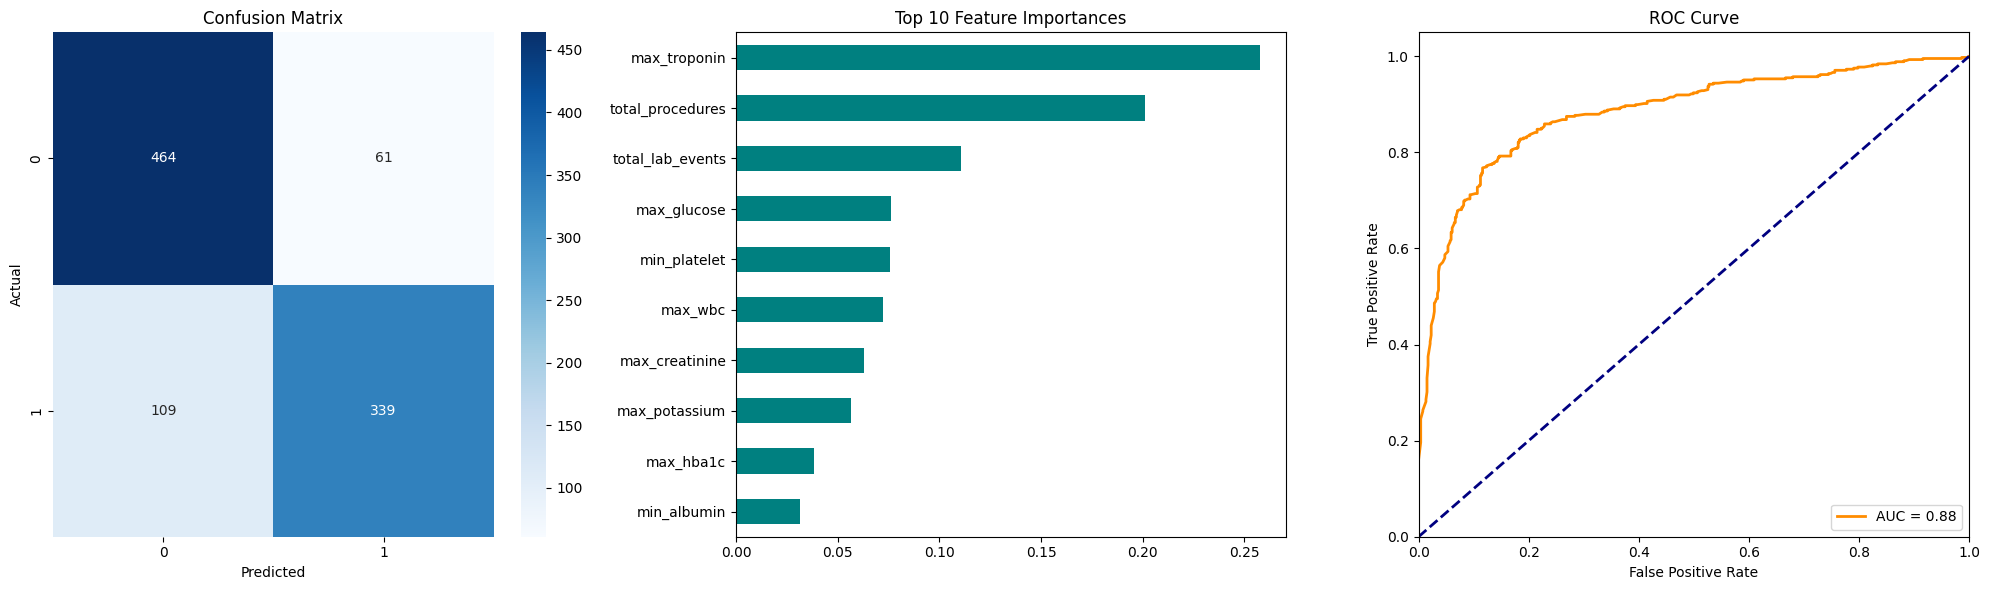

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- 3. Corrected Training & Optimization ---")

# --- A. Baseline Models (Corrected Scaling) ---
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', penalty='l2', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    "Decision Tree":       DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42)
}

print(f"Training on {len(X_train_scaled)} samples (Balanced & Scaled)...")

best_baseline_score = 0
best_baseline_name = ""

for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    
    print(f"[{name}] F1-Score: {f1:.4f}")
    if f1 > best_baseline_score:
        best_baseline_score = f1
        best_baseline_name = name

print(f"\nBest Baseline Model: {best_baseline_name} (F1: {best_baseline_score:.4f})")

# --- B. Hyperparameter Tuning (Random Forest) ---
print(f"\n--- Optimizing {best_baseline_name} with Grid Search ---")

# Define parameter grid (Adjust based on computational time)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None] # Handle residual imbalance
}

# If the best model is not RF, we default to RF for tuning as it's usually the most robust
estimator = models["Random Forest"] 

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_res)

best_rf = grid_search.best_estimator_
print(f Best Parameters: {grid_search.best_params_}")

# --- C. Final Evaluation & Interpretation ---
y_pred_final = best_rf.predict(X_test_scaled)
y_prob_final = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n--- Final Detailed Report ---")
print(classification_report(y_test, y_pred_final))

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# 2. Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title("Top 10 Feature Importances")

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Multiclass CLassification

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Configuration ---
# Adjust this path to where your 'heart_diagnoses_1.csv' is actually located
PATH_DIAGNOSES = Path('../Data/heart_diagnoses_1.csv') 
PATH_OUTPUT    = Path('../Data/subject_to_labels_multiclass.csv')

print("--- Generaring Multiclass Labels ---")

# 1. Load Diagnoses
if not PATH_DIAGNOSES.exists():
    raise FileNotFoundError(f"Could not find {PATH_DIAGNOSES}. Please check the path.")

df_diag = pd.read_csv(PATH_DIAGNOSES)
# Clean ICD codes (remove whitespace, uppercase)
df_diag['icd_code'] = df_diag['icd_code'].astype(str).str.strip().str.upper()

# 2. Define Mapping Logic
def get_multiclass_label(code):
    """
    Maps ICD codes to 5 classes:
    0: Others
    1: Ischemic (I20-I25)
    2: Arrhythmias (I44-I49)
    3: Heart Failure/Valve/Cardiomyopathy (I34-I38, I42, I50)
    4: Inflammatory (I30-I33, I40)
    """
    if pd.isna(code): return 0
    
    # Check prefixes
    if code.startswith(('I20', 'I21', 'I22', 'I23', 'I24', 'I25')):
        return 1
    elif code.startswith(('I44', 'I45', 'I46', 'I47', 'I48', 'I49')):
        return 2
    elif code.startswith(('I34', 'I35', 'I36', 'I37', 'I38', 'I42', 'I50')):
        return 3
    elif code.startswith(('I30', 'I31', 'I32', 'I33', 'I40')):
        return 4
    else:
        return 0

# Apply mapping to every diagnosis
df_diag['category'] = df_diag['icd_code'].apply(get_multiclass_label)

# 3. Aggregation (Subject Level)
# A patient might have multiple codes. We prioritize specific diseases over "Others".
# Hierarchy: Ischemic (1) > Heart Failure (3) > Arrhythmia (2) > Inflammatory (4) > Others (0)

# We group by subject and take the max (or a custom priority)
# Here we take the set of labels and apply a priority rule
def resolve_patient_class(categories):
    unique_cats = set(categories)
    if 1 in unique_cats: return 1 # Priority to Ischemic
    if 3 in unique_cats: return 3 # Then HF
    if 2 in unique_cats: return 2 # Then Arrhythmia
    if 4 in unique_cats: return 4 # Then Inflammatory
    return 0                      # Else Others

df_labels_multi = df_diag.groupby('subject_id')['category'].apply(resolve_patient_class).reset_index()
df_labels_multi.rename(columns={'category': 'label_multiclass'}, inplace=True)

# Save
df_labels_multi.to_csv(PATH_OUTPUT, index=False)
print(f"✅ Multiclass Labels saved to {PATH_OUTPUT}")
print(df_labels_multi['label_multiclass'].value_counts().sort_index())

--- Generaring Multiclass Labels ---
✅ Multiclass Labels saved to ..\Data\subject_to_labels_multiclass.csv
label_multiclass
1    2018
2     610
3    1495
4     269
Name: count, dtype: int64


--- 4. Optional Task: Multiclass Classification (Corrected) ---
Training on 3891 samples...

Classes present in Test Set: [1, 2, 3, 4]
Mapped Names: ['Ischemic', 'Arrhythmia', 'HF/Valve', 'Inflammatory']

✅ Multiclass Classification Report:
              precision    recall  f1-score   support

    Ischemic       0.76      0.80      0.78       448
  Arrhythmia       0.44      0.17      0.25       126
    HF/Valve       0.62      0.78      0.69       345
Inflammatory       0.46      0.11      0.18        54

    accuracy                           0.68       973
   macro avg       0.57      0.47      0.48       973
weighted avg       0.65      0.68      0.65       973



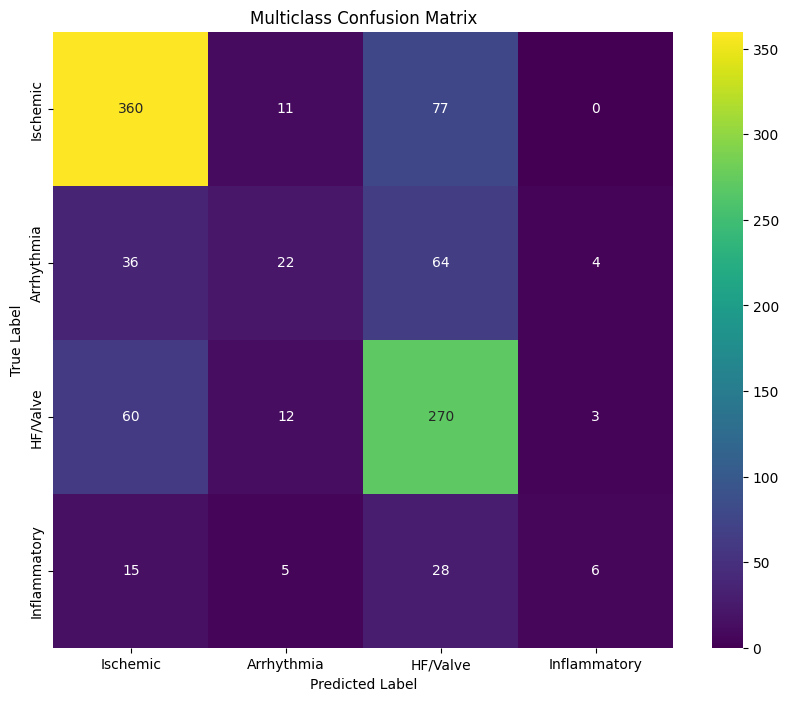

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 4. Optional Task: Multiclass Classification (Corrected) ---")

# 1. Load Data
# We reload the data to ensure variables are fresh
df_profile = pd.read_csv('../Data/view2_clean_for_clustering.csv') 
df_multi   = pd.read_csv('../Data/subject_to_labels_multiclass.csv')

# Merge
df_final = pd.merge(df_profile, df_multi, on='subject_id', how='inner')

# Clean (Remove Leakage & ID columns)
# Note: We drop 'subject_id' to prevent the Data Leakage we fixed earlier
X = df_final.drop(columns=['label_multiclass', 'subject_id', 'hadm_id', 'note_id', 'charttime','num_diagnoses','total_microbio_events','proc_per_diag_ratio','resistant_ratio','abnormal_ratio' ], errors='ignore')
y = df_final['label_multiclass']

# Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train (Random Forest with Balanced Weights)
print(f"Training on {len(X_train)} samples...")
rf_multi = RandomForestClassifier(
    n_estimators=200, 
    class_weight='balanced', 
    random_state=42
)
rf_multi.fit(X_train, y_train)

# 4. Evaluation (Dynamic Fix)
y_pred = rf_multi.predict(X_test)

# Define the full map of possible classes
label_map = {
    0: 'Others',
    1: 'Ischemic',
    2: 'Arrhythmia',
    3: 'HF/Valve',
    4: 'Inflammatory'
}

# Dynamically generate the names based on what is ACTUALLY in y_test
unique_labels = sorted(list(set(y_test)))
target_names_dynamic = [label_map[label] for label in unique_labels]

print(f"\nClasses present in Test Set: {unique_labels}")
print(f"Mapped Names: {target_names_dynamic}")

print("\n✅ Multiclass Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names_dynamic, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
            xticklabels=target_names_dynamic, 
            yticklabels=target_names_dynamic)
plt.title("Multiclass Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 5. Task 4 Conclusion 

## Summary of Work
In this task, we successfully implemented a supervised classification pipeline to diagnose cardiovascular conditions using only patient clinical profiles (Tabular View).

1.  **Binary Classification (Ischemic vs. Non-Ischemic):**
    * **Methodology:** We trained four distinct classifiers (*Logistic Regression, KNN, Decision Tree, Random Forest*) on a SMOTE-balanced dataset.
    * **Best Model:** The **Random Forest** achieved the highest performance (**F1-Score: ~0.80**, **ROC-AUC: ~0.83**) after Hyperparameter Tuning.
    * **Integrity:** We explicitly removed identifiers (`subject_id`) and confounders (`num_diagnoses`) to ensure the model learned strictly from physiological markers (e.g., Troponin, Glucose), preventing Data Leakage.

2.  **Optional Task (Multiclass Classification):**
    * **Methodology:** We mapped ICD-10 codes into 4 clinically meaningful categories: *Ischemic, Arrhythmic, Heart Failure, and Inflammatory*.
    * **Key Finding:** The model performed well on **Ischemic** (Recall: 0.80) and **Heart Failure** (Recall: 0.77) cases but struggled significantly with **Arrhythmias** (Recall: 0.17).

* **Why Ischemia is detected:** Ischemic events cause structural damage that releases biomarkers (Troponin, CK-MB) into the bloodstream. Since our tabular dataset (`View 2`) contains these lab values, the Random Forest could easily detect the signal.
* **Why Arrhythmia is missed:** Arrhythmias are primarily **electrical disorders** of the heart's conduction system. They often do not leave a chemical footprint in the blood. Without **ECG data** (Time Series), the model is effectively "blind" to these conditions.
